In [63]:
#added slippage stress test= slippage factor

In [38]:
#------IMPORTING LIBRARIES & OHLC DATA------

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

df = yf.download("AMZN", start="2005-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

breakout = 20
atr_mult = 3.5

[*********************100%***********************]  1 of 1 completed


In [39]:
#------STRATEGY------

def run_backtest(df, breakout, atr_mult, slip_factor = 1.0):
    df = df.copy()
    
    df['breakout_high'] = df['High'].shift(1).rolling(breakout).max()
    df['breakout_low'] = df['Low'].shift(1).rolling(breakout).min()
    df['sma200'] = df['Close'].rolling(200).mean()
    df['returns_std'] = df['Close'].pct_change(fill_method=None).rolling(breakout).std()
    df['true_range'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(
            abs(df['High'] - df['Close'].shift(1)),
            abs(df['Low'] - df['Close'].shift(1))
        )
    )
    df['atr'] = df['true_range'].rolling(14).mean()
    df['returns_std_ma'] = df['returns_std'].rolling(100).mean()
    
    capital = 100000
    cash = capital
    cost = 0.001
    position = 0
    entry_price = 0
    highest_price = None

    position_size = 0.7     #(locked after trying multiple values from 0.5-1)
    
    equity = []
    
    trades = []
    
    entry_idx = None
    
    position_history = []
    
    
    for i in range(len(df)):

        close = df['Close'].iloc[i]
        
        if i == len(df) - 1:
            equity.append(cash + position * close)
            position_history.append(1 if position > 0 else 0)
            break
            
        next_open = df['Open'].iloc[i+1]
        
        breakout_high = df['breakout_high'].iloc[i]
        breakout_low  = df['breakout_low'].iloc[i]
        sma = df['sma200'].iloc[i]
        returns_std = df['returns_std'].iloc[i]
        returns_std_ma = df['returns_std_ma'].iloc[i]
        atr = df['atr'].iloc[i]
        slippage = (0.1 * atr / close) * slip_factor #fixed one was 0.0005

        
        #NaN handling 
        if any(pd.isna(x) for x in [breakout_high, breakout_low, sma, returns_std, returns_std_ma, atr]):
            equity.append(cash + position * close)
            position_history.append(1 if position > 0 else 0)
            continue

            
        #  Entry 
        
        if position == 0:
    
            if close > breakout_high:
    
                entry_price = next_open * (1 + cost/2 + slippage)
                shares = (cash * position_size) / entry_price
                
                position = shares
                cash -= shares * entry_price
                
                highest_price = close
                entry_idx = i # Real cash deduction model 
    
        #  Exit
        
        elif position > 0:
            
            
            if highest_price is None:
                highest_price = close
            else:
                highest_price = max(highest_price, close)
            
            atr_stop = highest_price - atr_mult * atr
            donchian_stop = breakout_low
            
            exit_level = max(donchian_stop, atr_stop)
    
            
            #ATR-based Exit (replaced low20 exit)
            
            if close <  exit_level:
                    exit_price = next_open * (1 - cost/2 - slippage)
                   
                    pnl = (exit_price - entry_price) / entry_price
                    duration = i - entry_idx
                    trades.append((pnl, duration)) 
        
                    cash += position * exit_price
                    position = 0
                    entry_price = 0
                    entry_idx = None
                    highest_price = None
    
        #  Equity
        
        equity.append(cash + position * close)
        position_history.append(1 if position > 0 else 0)
    
    
    
        #  Performance metrics
    
    equity = pd.Series(equity, index=df.index)
    
    # Returns
    
    returns = equity.pct_change()
    
    # CAGR(time-based)
    
    years = (df.index[-1] - df.index[0]).days / 365.25
    
    if years > 0:
        cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    else:
        cagr = np.nan
    
    # Vol / Sharpe
    
    if returns.std() > 0:
        vol_ann = returns.std() * np.sqrt(252)
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    else:
        vol_ann = sharpe = np.nan
        
    # Sortino
    
    downside = returns[returns < 0]
    sortino = (returns.mean() / downside.std()) * np.sqrt(252) if downside.std() > 0 else np.nan

    downside = returns[returns < 0]

    if len(downside) > 0 and downside.std() > 0:
        sortino = (returns.mean() / downside.std()) * np.sqrt(252)
    else:
        sortino = np.nan
        
    # Drawdowns
    
    cum_max = equity.cummax()
    drawdown = equity / cum_max - 1
    
    max_dd = drawdown.min()
    avg_dd = drawdown[drawdown < 0].mean()
    
    # Drawdown Duration
    
    dd_flag = (drawdown < 0).astype(int)
    
    dd_duration = (
        dd_flag.groupby((dd_flag != dd_flag.shift()).cumsum())
        .cumsum()
    )
    
    max_dd_duration = dd_duration.max()
    avg_dd_duration = dd_duration[dd_duration > 0].mean()
    
    
    #  Trade Stats
    
    if len(trades) > 0:
        trade_returns = np.array([t[0] for t in trades])
        trade_durations = np.array([t[1] for t in trades])
    
        win_rate = (trade_returns > 0).mean()
    
        wins = trade_returns[trade_returns > 0]
        losses = trade_returns[trade_returns < 0]
    
        profit_factor = (
            wins.sum() / abs(losses.sum())
            if len(losses) > 0 else np.nan
        )
    
        expectancy = trade_returns.mean()
        best_trade = trade_returns.max()
        worst_trade = trade_returns.min()
    
        max_trade_duration = trade_durations.max()
        avg_trade_duration = trade_durations.mean()
    
        # SQN
        
        if len(trade_returns) > 1 and trade_returns.std() > 0:
            sqn = (trade_returns.mean() / trade_returns.std()) * np.sqrt(len(trade_returns))
        else:
            sqn = np.nan
    
        # Kelly
        if len(wins) > 0 and len(losses) > 0:
            kelly = win_rate - (1 - win_rate) / (wins.mean() / abs(losses.mean()))
        else:
            kelly = np.nan
    
    else:
        win_rate = profit_factor = expectancy = np.nan
        best_trade = worst_trade = np.nan
        max_trade_duration = avg_trade_duration = sqn = kelly = np.nan
    
    # Exposure
    
    exposure = np.mean(position_history)
    
    # Buy & Hold
    
    buy_hold = df['Close'].iloc[-1] / df['Close'].iloc[0] - 1
    
    
    # returning results
    
    return {
        "cagr": cagr,
        "sharpe": sharpe,
        "sortino": sortino,
        "vol_ann": vol_ann,
        "max_dd": max_dd,
        "avg_dd": avg_dd,

        
        "max_dd_duration": max_dd_duration,
        "avg_dd_duration": avg_dd_duration,
        
        "trades": trades,
        "win_rate": win_rate,
        "profit_factor": profit_factor,
        "expectancy": expectancy,
        
        "best_trade": best_trade,
        "worst_trade": worst_trade,
        "sqn": sqn,
        "kelly": kelly,
        
        "exposure": exposure,
        "buy_hold": buy_hold,
        "equity": equity
    }

In [40]:
#------BACKTEST EXPORT CSV------

#   Run backtest

results = run_backtest(df, breakout=20, atr_mult=3.5)


import os

os.makedirs(

    "results/backtests",
    exist_ok=True

)

metrics_df = pd.DataFrame(

    [
        (k, v)
        
        for k, v in results.items()
        
        if k not in ["trades", "equity"]
    ],

    columns=["Metric", "Value"]

)

metrics_df.to_csv(
    
    "results/backtests/bt_results/backtest_metrics_summary.csv",
    index=False

)

#  Export Markdown

backtest_summary = f"""

# Backtest Summary

- CAGR: {results['cagr']:.4f}

- Sharpe: {results['sharpe']:.4f}

- Sortino: {results['sortino']:.4f}

- Max Drawdown: {results['max_dd']:.4f}

- Average Drawdown: {results['avg_dd']:.4f}

- Max Drawdown Duration: {results['max_dd_duration']:.4f}

- Average Drawdown Duration": {results['avg_dd_duration']:.4f}

- Win Rate: {results['win_rate']:.4f}

- Profit Factor: {results['profit_factor']:.4f}

- Expectancy: {results['expectancy']:.4f}

- Best Trade: {results['best_trade']:.4f}

- Worst Trade: {results['worst_trade']:.4f}

- SQN: {results['sqn']:.4f}

- Kelly Fraction: {results['kelly']:.4f}

- Exposure: {results['exposure']:.4f}

- Buy & Hold Return: {results['buy_hold']:.4f}

"""



with open("results/backtests/bt_results/backtest_summary.md", "w") as f:

    f.write(backtest_summary)

print("Exports complete.")

print("\nMetrics exported to:")
print("systematic-trade-research/results/backtest/backtest_metrics_summary.csv")

Exports complete.

Metrics exported to:
systematic-trade-research/results/backtest/backtest_metrics_summary.csv


In [41]:
#  Exporting Backtest equity curve
                                                                     
plt.figure(figsize=(12,6))

results["equity"].plot()

plt.title("Equity Curve")

plt.savefig(

    "results/backtests/equity_curve.png",

    bbox_inches="tight"

)

plt.close()

print("Equity curve exported.")

Equity curve exported.


In [42]:
#------PARAMETER GRID SEARCH------

def score_fn(grid_res):

    return (

        grid_res["cagr"] * 0.4 +

        grid_res["sharpe"] * 0.4 +

        grid_res["max_dd"] * 0.2   # already negative → penalizes DD

    )

results = []

for atr_mult in [3.5, 4.0, 4.5, 5.0]:

    for breakout in [15, 18, 20, 22, 25]:

        grid_res = run_backtest(df.copy(), breakout, atr_mult)

        results.append({

            "breakout": breakout,

            "atr": atr_mult,

            "cagr": grid_res["cagr"],

            "sharpe": grid_res["sharpe"],

            "max_dd": grid_res["max_dd"],

            "score": score_fn(grid_res)   # ✅ weighted score

        })

df_results = pd.DataFrame(results)


df_results = df_results.sort_values("score", ascending=False).reset_index(drop=True)

#clean ranking column

df_results.insert(0, "rank", df_results.index + 1)


df_results.head().style.format({

    "atr": "{:.1f}"

}).hide(axis="index")



rank,breakout,atr,cagr,sharpe,max_dd,score
1,20,3.5,0.102295,0.607468,-0.309401,0.222025
2,25,3.5,0.099104,0.598637,-0.366473,0.205802
3,22,3.5,0.097111,0.593737,-0.361405,0.204058
4,20,4.5,0.100226,0.581367,-0.405735,0.191490
5,18,3.5,0.093518,0.564269,-0.367727,0.189569


In [43]:
#  Exporting Parameter Stability results

df_results.to_csv(

    "results/backtests/parameter_stability_tests/parameter_stability_results.csv",

    index=False

)

In [44]:
#  Parameter Stability Test summary

summary = f"""

# Parameter Stability Test

Best Parameter Set

- Breakout: {df_results.iloc[0]['breakout']}

- ATR: {df_results.iloc[0]['atr']}

- CAGR: {df_results.iloc[0]['cagr']:.4f}

- Sharpe: {df_results.iloc[0]['sharpe']:.4f}

- Max DD: {df_results.iloc[0]['max_dd']:.4f}

- Score: {df_results.iloc[0]['score']:.4f}

Total parameter combinations tested: {len(df_results)}

"""

with open(

    "results/backtests/parameter_stability_tests/summary_paramstab.md",

    "w"

) as f:

    f.write(summary)

In [45]:
#  Parameter Stability Heatmap plot

pivot = df_results.pivot(

    index="atr",

    columns="breakout",

    values="score"

)

plt.figure(figsize=(8,6))

plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Weighted Score")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Parameter Stability Heatmap")

plt.figtext(
    0.5,
    -0.08,
    "Weighted Score = 0.4×CAGR + 0.4×Sharpe + 0.2×MaxDD (higher is better)",
    ha="center",
    fontsize=9
)

plt.savefig(
    "results/backtests/parameter_stability_tests/parameter_stability_heatmap.png",
    bbox_inches="tight"
)

plt.close()

In [46]:
#------SLIPPAGE STRESS TESTS PARAMETER GRID------

params = [
    (18, 3.5), (20, 3.5), (22, 3.5), (25, 3.5),

    (18, 4.0), (20, 4.0), (22, 4.0), (25, 4.0),

    (18, 4.5), (20, 4.5), (22, 4.5), (25, 4.5),

    (18, 5.0), (20, 5.0), (22, 5.0), (25, 5.0)
]

def slippage_test_grid(df, params, factors=[0.5, 1.0, 2.0]):

    rows = []

    for breakout, atr in params:

        for factor in factors:

            slip_res = run_backtest(df.copy(), breakout, atr, slip_factor=factor)

            rows.append({

                "breakout": breakout,

                "atr": atr,

                "slip_factor": factor,

                "cagr": slip_res["cagr"],

                "sharpe": slip_res["sharpe"],

                "max_dd": slip_res["max_dd"],

                "score": score_fn(slip_res)

            })
    
    #Was return pd.DataFrame(rows) earlier, did the below to prevent the index starting from 1
    
    df_out = pd.DataFrame(rows)
    
    #sort → higher score = better

    df_out = df_out.sort_values("score", ascending=False).reset_index(drop=True)

    #rank column

    df_out.insert(0, "rank", df_out.index + 1)

    return df_out

slippage_test_grid(df, params).head().style.format({
    "atr": "{:.1f}",
    "slip_factor": "{:.1f}"
}).hide(axis="index")

rank,breakout,atr,slip_factor,cagr,sharpe,max_dd,score
1,20,3.5,0.5,0.109159,0.641048,-0.300258,0.240031
2,25,3.5,0.5,0.105110,0.628620,-0.356950,0.222102
3,20,3.5,1.0,0.102295,0.607468,-0.309401,0.222025
4,22,3.5,0.5,0.103532,0.626180,-0.353675,0.221150
5,18,3.5,0.5,0.100911,0.600568,-0.355523,0.209487


In [47]:
#  Exporting Slippage metrics

slippage_df = slippage_test_grid(df, params)

slippage_df.to_csv(

    "results/backtests/slippage_stress_tests/slippage_stress_results.csv",

    index=False

)

In [48]:
#  Slippage summary
summary = f"""

# Slippage Stress Test

Best Result Under Slippage

- Breakout: {slippage_df.iloc[0]['breakout']}

- ATR: {slippage_df.iloc[0]['atr']}

- Slippage Factor: {slippage_df.iloc[0]['slip_factor']}

- CAGR: {slippage_df.iloc[0]['cagr']:.4f}

- Sharpe: {slippage_df.iloc[0]['sharpe']:.4f}

- Max DD: {slippage_df.iloc[0]['max_dd']:.4f}

- Score: {slippage_df.iloc[0]['score']:.4f}

Total tests: {len(slippage_df)}

"""

with open(

    "results/backtests/slippage_stress_tests/summary.md",

    "w"

) as f:

    f.write(summary)

In [49]:
#  Slippage plot

slippage_df.groupby("slip_factor")["cagr"].mean().plot(

    marker="o",

    figsize=(8,5)

)

plt.title("Average CAGR vs Slippage")

plt.ylabel("CAGR")

plt.savefig(

    "results/backtests/slippage_stress_tests/slippage_vs_cagr.png",

    bbox_inches="tight"

)

plt.close()

In [50]:
#------FIXED PARAMS WALKFORWARD TESTING------

def walkforward(df, breakout, atr_mult, train_years=6, test_years=2):

    df = df.copy()
    df['year'] = df.index.year

    years = sorted(df['year'].unique())

    results = []

    start_idx = 0


    while True:
        train_start = years[start_idx]
        train_end   = train_start + train_years - 1
        test_end    = train_end + test_years

        # stop if not enough data
        if test_end > years[-1]:
            break

        # slice
        train_df = df[(df['year'] >= train_start) & (df['year'] <= train_end)].copy()
        test_df  = df[(df['year'] > train_end)  & (df['year'] <= test_end)].copy()

        # run ONLY on test (since params are frozen)

        test_res = run_backtest(test_df, breakout, atr_mult)

        results.append({

            "train_period": f"{train_start}-{train_end}",
            "test_period": f"{train_end+1}-{test_end}",
        
            "cagr": test_res["cagr"],
            "sharpe": test_res["sharpe"],
            "sortino": test_res["sortino"],
            "vol_ann": test_res["vol_ann"],
        
            "max_dd": test_res["max_dd"],
            "avg_dd": test_res["avg_dd"],
            "max_dd_duration": test_res["max_dd_duration"],
            "avg_dd_duration": test_res["avg_dd_duration"],
        
            "trades": test_res["trades"],
            "win_rate": test_res["win_rate"],
            "profit_factor": test_res["profit_factor"],
            "expectancy": test_res["expectancy"],
        
            "best_trade": test_res["best_trade"],
            "worst_trade": test_res["worst_trade"],
            "sqn": test_res["sqn"],
            "kelly": test_res["kelly"],
                    
            "exposure": test_res["exposure"],
            "buy_hold": test_res["buy_hold"]
        })

        start_idx += test_years  # roll forward

    return pd.DataFrame(results) 

In [51]:
#  Printing fixed param walkforward results

wf = walkforward(df, breakout=20, atr_mult=3.5)
wf 

,train_period,test_period,cagr,sharpe,sortino,vol_ann,max_dd,avg_dd,max_dd_duration,avg_dd_duration,trades,win_rate,profit_factor,expectancy,best_trade,worst_trade,sqn,kelly,exposure,buy_hold
0,2005-2010,2011-2012,-0.008272,-0.018688,-0.017072,0.111836,-0.144638,-0.065924,232,113.630252,"[(-0.06885646438739278, 27), (-0.0209322466026...",0.250000,0.648957,-0.014114,0.104364,-0.071030,-0.396039,-0.135234,0.336653,0.361796
1,2007-2012,2013-2014,-0.020430,-0.129717,-0.092783,0.111201,-0.173502,-0.083950,239,100.510417,"[(0.17700726384862653, 66), (-0.08780121947176...",0.200000,0.803681,-0.008648,0.177007,-0.087801,-0.201934,-0.048855,0.285714,0.206133
2,2009-2014,2015-2016,0.130927,1.123084,1.176745,0.115281,-0.084150,-0.032670,73,26.000000,"[(0.12634279552080602, 53), (0.190422059400446...",1.000000,NaN,0.122726,0.190422,0.051414,3.741918,NaN,0.424603,1.430539
3,2011-2016,2017-2018,0.155435,1.332002,1.079303,0.113466,-0.104295,-0.047257,87,31.274590,"[(0.27602176460080846, 103), (0.16757529305687...",1.000000,NaN,0.221799,0.276022,0.167575,5.784798,NaN,0.430279,0.992875
4,2013-2018,2019-2020,0.170799,1.117281,1.129822,0.151015,-0.148652,-0.055868,83,20.095238,"[(0.08337206826579827, 76), (0.575030382213811...",0.666667,7.081868,0.188477,0.575030,-0.092970,1.154947,0.572530,0.400000,1.116085
5,2015-2020,2021-2022,0.000433,0.057843,0.044819,0.109028,-0.125399,-0.071724,175,68.258503,"[(-0.02806876329569572, 44), (-0.0531881170631...",0.333333,1.061874,0.001676,0.086285,-0.053188,0.047821,0.019423,0.174950,-0.472797
6,2017-2022,2023-2024,0.138050,1.132400,1.322669,0.120923,-0.098691,-0.041985,145,44.248000,"[(0.2670253103955695, 116), (-0.04826116243525...",0.500000,5.532923,0.109382,0.267025,-0.048261,0.981264,0.409632,0.422311,1.556397
7,2019-2024,2025-2026,-0.045975,-0.288413,-0.162213,0.133592,-0.201776,-0.116882,157,77.556250,"[(-0.041351728413760724, 15), (-0.159105403618...",0.333333,0.581080,-0.027992,0.116482,-0.159105,-0.429420,-0.240311,0.204360,0.057079


In [52]:
#  Printing fixed param walkforward performance summary

print("Avg CAGR:", wf['cagr'].mean())
print("Median CAGR:", wf['cagr'].median())
print("Worst CAGR:", wf['cagr'].min())

print("Avg Sharpe:", wf['sharpe'].mean())
print("Worst DD:", wf['max_dd'].min())
print("CAGR:", wf['cagr'].max())
print("Win % (CAGR > 0):", (wf['cagr'] > 0).mean())   #PERIOD WIN PERCENTAGE
print("Avg Trade Win Rate:", wf['win_rate'].mean())   #WIN RATE (Trade-level)

Avg CAGR: 0.06512066020915025
Median CAGR: 0.06567982750205692
Worst CAGR: -0.045975468539524056
Avg Sharpe: 0.5407241133718004
Worst DD: -0.2017755110887094
CAGR: 0.17079859175476786
Win % (CAGR > 0): 0.625
Avg Trade Win Rate: 0.5354166666666667


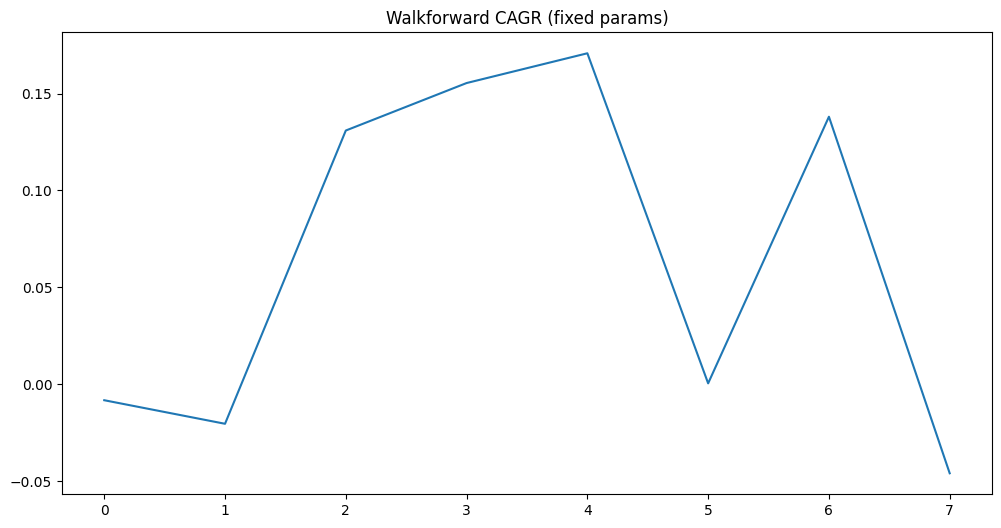

In [53]:
#  Exporting Fixed param wf performance summary:


summary = f"""

# Fixed Parameters Walkforward Summary

- Avg CAGR: {wf['cagr'].mean():.4f}

- Median CAGR: {wf['cagr'].median():.4f}

- Worst CAGR: {wf['cagr'].min():.4f}

- Avg Sharpe: {wf['sharpe'].mean():.4f}

- Worst Drawdown: {wf['max_dd'].min():.4f}

- Best CAGR: {wf['cagr'].max():.4f}

- Positive Window %: {(wf['cagr'] > 0).mean():.4f}

- Avg Trade Win Rate: {wf['win_rate'].mean():.4f}

- Number of Walkforward Windows: {len(wf)}

"""

wf.to_csv(

    "results/walkforwards/fixed_params_walkforward_test/fixed_params_wf_result/wf.csv",

    index=False

)

# Performance metrics summary: 

with open(

    "results/walkforwards/fixed_params_walkforward_test/fixed_params_wf_result/summary.md",

    "w"

) as f:

    f.write(summary)

    
# Printing CAGR curve plot and exporting it

plt.figure(figsize=(12,6))

wf["cagr"].plot()

plt.title("Walkforward CAGR (fixed params)")


plt.savefig(

    "results/walkforwards/fixed_params_walkforward_test/fixed_params_wf_result/wf_fixedparams_equity_curve.png",
    
    bbox_inches="tight"

)

In [54]:
#------ROLLING WALKFORWARD OPTIMIZATION------

def walkforward_optimized(df, params, train_years=6, test_years=2):

    df = df.copy()
    df["year"] = df.index.year
    years = sorted(df["year"].unique())

    results = []
    start_idx = 0

    while True:
        train_start = years[start_idx]
        train_end = train_start + train_years - 1
        test_end = train_end + test_years

        if test_end > years[-1]:
            break

        #  Slice Data 
        train_df = df[(df["year"] >= train_start) & (df["year"] <= train_end)].copy()
        test_df  = df[(df["year"] > train_end) & (df["year"] <= test_end)].copy()

        #  Optimization (Train only)
        best_score = -1e9
        best_params = None
        best_train_res = None

        for breakout, atr in params:
            train_res = run_backtest(train_df.copy(), breakout, atr)

            score = score_fn(train_res)

            if score > best_score:
                best_score = score
                best_params = (breakout, atr)
                best_train_res = train_res

        #  Test (OOS)
        test_res = run_backtest(test_df.copy(), best_params[0], best_params[1])

        results.append({
            "train_period": f"{train_start}-{train_end}",
            "test_period": f"{train_end+1}-{test_end}",

            "breakout": best_params[0],
            "atr": round(best_params[1], 1),

            "train_cagr": best_train_res["cagr"],
            "train_sharpe": best_train_res["sharpe"],
            "train_max_dd": best_train_res["max_dd"],
            "train_win_rate": best_train_res["win_rate"],

            "test_cagr": test_res["cagr"],
            "test_sharpe": test_res["sharpe"],
            "test_max_dd": test_res["max_dd"],

            "test_win_rate": test_res["win_rate"],

            "test_trades": len(test_res["trades"]),
        })

        start_idx += test_years  # roll forward

    return pd.DataFrame(results)

In [55]:
#  Printing rolling window walkforward results

wf_opt = walkforward_optimized(df, params)

wf_opt.head()

,train_period,test_period,breakout,atr,train_cagr,train_sharpe,train_max_dd,train_win_rate,test_cagr,test_sharpe,test_max_dd,test_win_rate,test_trades
0,2005-2010,2011-2012,18,3.5,0.137191,0.635922,-0.237610,0.388889,-0.008272,-0.018688,-0.144638,0.250000,4
1,2007-2012,2013-2014,18,3.5,0.076102,0.443403,-0.244366,0.388889,-0.009801,-0.034904,-0.155530,0.200000,5
2,2009-2014,2015-2016,22,4.0,0.087971,0.608479,-0.170758,0.642857,0.105259,0.944781,-0.094501,1.000000,3
3,2011-2016,2017-2018,25,4.0,0.134512,0.877557,-0.151416,0.800000,0.108134,0.921835,-0.117046,1.000000,2
4,2013-2018,2019-2020,22,3.5,0.143581,1.009117,-0.161930,0.642857,0.157181,1.053098,-0.168300,0.666667,3


In [65]:
#  Exporting Rolling Walkforward Test CAGR By Window

plt.figure(figsize=(12,6))

plt.plot(

    wf_opt["test_period"],

    wf_opt["test_cagr"],

    marker="o"

)

plt.title("Rolling Walkforward Test CAGR by Window")

plt.ylabel("CAGR")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(

    "results/walkforwards/rolling_window_walkforward_test/rolling_wfo_result/rolling_wfo_test_cagr_by_window.png",

    bbox_inches="tight"

)

plt.close()

In [59]:
#  Printing rolling window walkforward performace summary

print("Avg CAGR:", wf_opt['test_cagr'].mean())
print("Median CAGR:", wf_opt['test_cagr'].median())
print("Worst CAGR:", wf_opt['test_cagr'].min())

print("Avg Sharpe:", wf_opt['test_sharpe'].mean())
print("Worst DD:", wf_opt['test_max_dd'].min())
print("CAGR:", wf_opt['test_cagr'].max())
print("Win % (CAGR > 0):", (wf_opt['test_cagr'] > 0).mean())  #PERIOD WIN PERCENTAGE
print("Avg Trade Win Rate:", wf_opt['test_win_rate'].mean())  #WIN RATE (Trade-level)

Avg CAGR: 0.05495326213047079
Median CAGR: 0.05015464192446062
Worst CAGR: -0.045975468539524056
Avg Sharpe: 0.4641684105953788
Worst DD: -0.2017755110887094
CAGR: 0.15718145665059002
Win % (CAGR > 0): 0.5
Avg Trade Win Rate: 0.5354166666666667


In [64]:
#  Rolling Walkforward Performance Summary

summary = f"""

# Rolling Walkforward Optimization Summary

- Avg Test CAGR: {wf_opt['test_cagr'].mean():.4f}

- Median Test CAGR: {wf_opt['test_cagr'].median():.4f}

- Worst Test CAGR: {wf_opt['test_cagr'].min():.4f}

- Avg Test Sharpe: {wf_opt['test_sharpe'].mean():.4f}

- Worst Test Drawdown: {wf_opt['test_max_dd'].min():.4f}

- Best Test CAGR: {wf_opt['test_cagr'].max():.4f}

- Positive Test Window %: {(wf_opt['test_cagr'] > 0).mean():.4f}

- Avg Trade Win Rate: {wf_opt['test_win_rate'].mean():.4f}

"""

with open(

    "results/walkforwards/rolling_window_walkforward_test/rolling_wfo_result/summary.md",

    "w"

) as f:

    f.write(summary)

wf_opt
wf_opt.to_csv("results/walkforwards/rolling_window_walkforward_test/rolling_wfo_result/wfo_metrics.csv", index=False)

In [66]:
#------ROLLING WINDOW PARAMETER STABILITY TEST-----

stability = (

    wf_opt[['breakout','atr']]

    .value_counts()

    .reset_index(name='count')

)

stability['pct_windows'] = (

    stability['count']

    / stability['count'].sum()

)

stability.to_csv(

    "results/walkforwards/rolling_window_walkforward_test/rolling_wf_param_stability/parameter_stability.csv",

    index=False

)

stability

,breakout,atr,count,pct_windows
0,18,3.5,2,0.250
1,25,3.5,2,0.250
2,20,3.5,1,0.125
3,22,3.5,1,0.125
4,22,4.0,1,0.125
5,25,4.0,1,0.125


In [67]:
#  Rolling Walkforward Parameter Stability Summary

summary = f"""

# Rolling WFO Parameter Stability

Most Selected Parameter Set

- Breakout: {stability.iloc[0]['breakout']}

- ATR: {stability.iloc[0]['atr']}

- Selected in: {stability.iloc[0]['pct_windows']:.2%} of windows

- Number of Unique Parameter Combinations: {len(stability)}

- Total Walkforward Windows: {stability['count'].sum()}

Interpretation:

Higher concentration suggests stable parameter selection across time.

Lower concentration suggests the optimizer frequently changes parameter choices.

"""

with open(

    "results/walkforwards/rolling_window_walkforward_test/rolling_wf_param_stability/summary.md",

    "w"

) as f:

    f.write(summary)

In [68]:
#  Plotting and exporting Rolling Window wf parameter stability frequency plot

stability['params'] = (

    stability['breakout'].astype(str)

    + " / "

    + stability['atr'].astype(str)

)

plt.figure(figsize=(8,5))

plt.bar(

    stability['params'],

    stability['pct_windows']

)

plt.title("Rolling WFO Parameter Stability")

plt.ylabel("Fraction of Windows")

plt.xlabel("Breakout / ATR")

plt.tight_layout()

plt.savefig(

    "results/walkforwards/rolling_window_walkforward_test/rolling_wf_param_stability/parameter_frequency.png",

    bbox_inches="tight"

)

plt.close()

In [69]:
#------Walkforward Consistency Check (Loss clustering analysis)------


def consistency_check(series):

    neg = (series < 0).astype(int)

    streaks = neg.groupby((neg != neg.shift()).cumsum()).cumsum()

    return {

        "max_consecutive_losses": int(streaks.max()),

        "worst_3_period_loss_cluster": float(neg.rolling(3).mean().max())

    }
    

rolling_consistency = consistency_check(wf_opt["test_cagr"])

fixed_consistency = consistency_check(wf["cagr"])

consistency_df = pd.DataFrame([
    {
        "walkforward_type": "rolling",
        **rolling_consistency
    },

    {
        "walkforward_type": "fixed",
        **fixed_consistency
    }
])

#  Exporting results

consistency_df.to_csv(
    "results/walkforwards/fixed_and_rolling_wf_consistency_check/consistency_results.csv",
    index=False
)

consistency_df

,walkforward_type,max_consecutive_losses,worst_3_period_loss_cluster
0,rolling,2,0.666667
1,fixed,2,0.666667
